# <p align  = "center"> Data Analysis </p>

In [2]:
#Initialize Notebook Environment
from pathlib import Path
import sys
sys.path.insert( 0, Path("../..").resolve().absolute().__str__() )

- Loading Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xaidar.filesUtils import loadPickle

dataDir = Path( "../../data/s3Sizes/xchem/filetypes" )
dataStats = loadPickle( dataDir / "stats_filetype_sizes.pkl" )
dataStats_df = pd.DataFrame( dataStats )

display( dataStats_df.head(2))


,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
0,.log,72432555,22241.0,7.138445e+04,8.874021e+07,9089.0,39965.0,15438.0,533624546212,0,5170557845206
1,.pickle,5487500,207065.0,9.074811e+06,1.304883e+08,79927.0,1804069.0,862071.0,41406355830,5,49798026455013


In [4]:
# Table Hihgest Sum
display( dataStats_df.sort_values(by=[ "Sum", "Files Count",], ascending=[False, False])[:2])

,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
309,.ccp4,9915981,13825104.0,2.139495e+07,2.676578e+07,7373904.0,24884224.0,8755160.0,924209200,0,212151888883999
11,.mtz,28044913,2396048.0,4.986313e+06,1.107045e+07,1233140.0,4814912.0,1790886.0,1704377676,0,139840708420084


In [5]:
# Table Highest Count
display( dataStats_df.sort_values(by=[ "Files Count", "Sum",], ascending=[False, False])[:2])

,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
5,.pdb,92298857,3018.0,88430.451357,2.776189e+05,1833.0,11219.0,4693.0,367507276,0,8162029584229
0,.log,72432555,22241.0,71384.446472,8.874021e+07,9089.0,39965.0,15438.0,533624546212,0,5170557845206


In [6]:
# Table Highest Median
display( dataStats_df.sort_values(by=[ "Median", "Files Count",], ascending=[False, False])[:2])

,File Type,Files Count,Median,Mean,Std,1stQrt,3rdQrt,QrtDeviation,Max,Min,Sum
101565,.hdf5,67,1.763062e+10,1.121691e+10,1.128880e+10,9.395126e+08,2.002573e+10,9.543108e+09,60175822312,195,751532744400
143225,.nfs00000000a579c25f00000013,9,9.734263e+09,9.734263e+09,0.000000e+00,9.734263e+09,9.734263e+09,0.000000e+00,9734262784,9734262784,87608365056


- Totals Statisic Values

In [7]:
bucketSize = dataStats_df["Sum"].sum()
bucketCount = dataStats_df["Files Count"].sum()
bucketMedians = dataStats_df["Median"].sum()

print( f"Total bucket size: {round( bucketSize / 1e12, 2)} TB" )
print( f"Total files count: {round( bucketCount / 1e6 , 2)} Million" )

Total bucket size: 597.8 TB
Total files count: 457.39 Million


- Per File Type Statistics

In [8]:
# Filtering Odd Files
import re

lstFileTypes = list(dataStats_df["File Type"].values)

removedFileTypes = [ file for file in list(lstFileTypes) if re.search( "^\\....[0-9][0-9][0-9]", file) ] 
updatedFileTypes = [ file for file in list(lstFileTypes) if not re.search( "^\\....[0-9][0-9][0-9]", file)]

removedFileTypes.extend( [ file for file in updatedFileTypes if  re.search( "^\\.[0-9][0-9][0-9][0-9]", file)] )# i.e. .21610_VDW_R
updatedFileTypes = [ file for file in updatedFileTypes if not re.search( "^\\.[0-9][0-9][0-9][0-9]", file)]  # i.e. .21610_VDW_R

removedFileTypes.extend( [ file for file in updatedFileTypes if  re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)] )
updatedFileTypes = [ file for file in updatedFileTypes if not re.search( "[0-9][0-9][0-9][0-9][0-9][0-9][0-9]", file)]  


updatedFileTypes = sorted( updatedFileTypes)
removedFileTypes = sorted( removedFileTypes)

print(f"Number of File types after removing odds ones: {len(updatedFileTypes)}")
print(f"Number of Removed File types: {len(removedFileTypes)}")

# # Displaying removed file types
# for i in range( len( removedFileTypes[:] )//20 ):
#     # print( removedFileTypes[i*20:(i+1)*20] )
#     print( removedFileTypes[-(i+1)*20: -i*20:] )

Number of File types after removing odds ones: 7409
Number of Removed File types: 247880


In [9]:
# Instantiate Objects to Plot
sums =  dataStats_df.sort_values( by=[ "Sum"], ascending=[False] )
counts =  dataStats_df.sort_values( by=[ "Files Count"], ascending=[False] ) 
median = dataStats_df.sort_values( by=[ "Median"], ascending=[False] ) 
setRemovedFileTypes = set(removedFileTypes)
filteredMedian = dataStats_df[ ( [fileType not in setRemovedFileTypes for fileType in  dataStats_df["File Type"] ]  )].sort_values( by=[ "Median"], ascending=[False] )

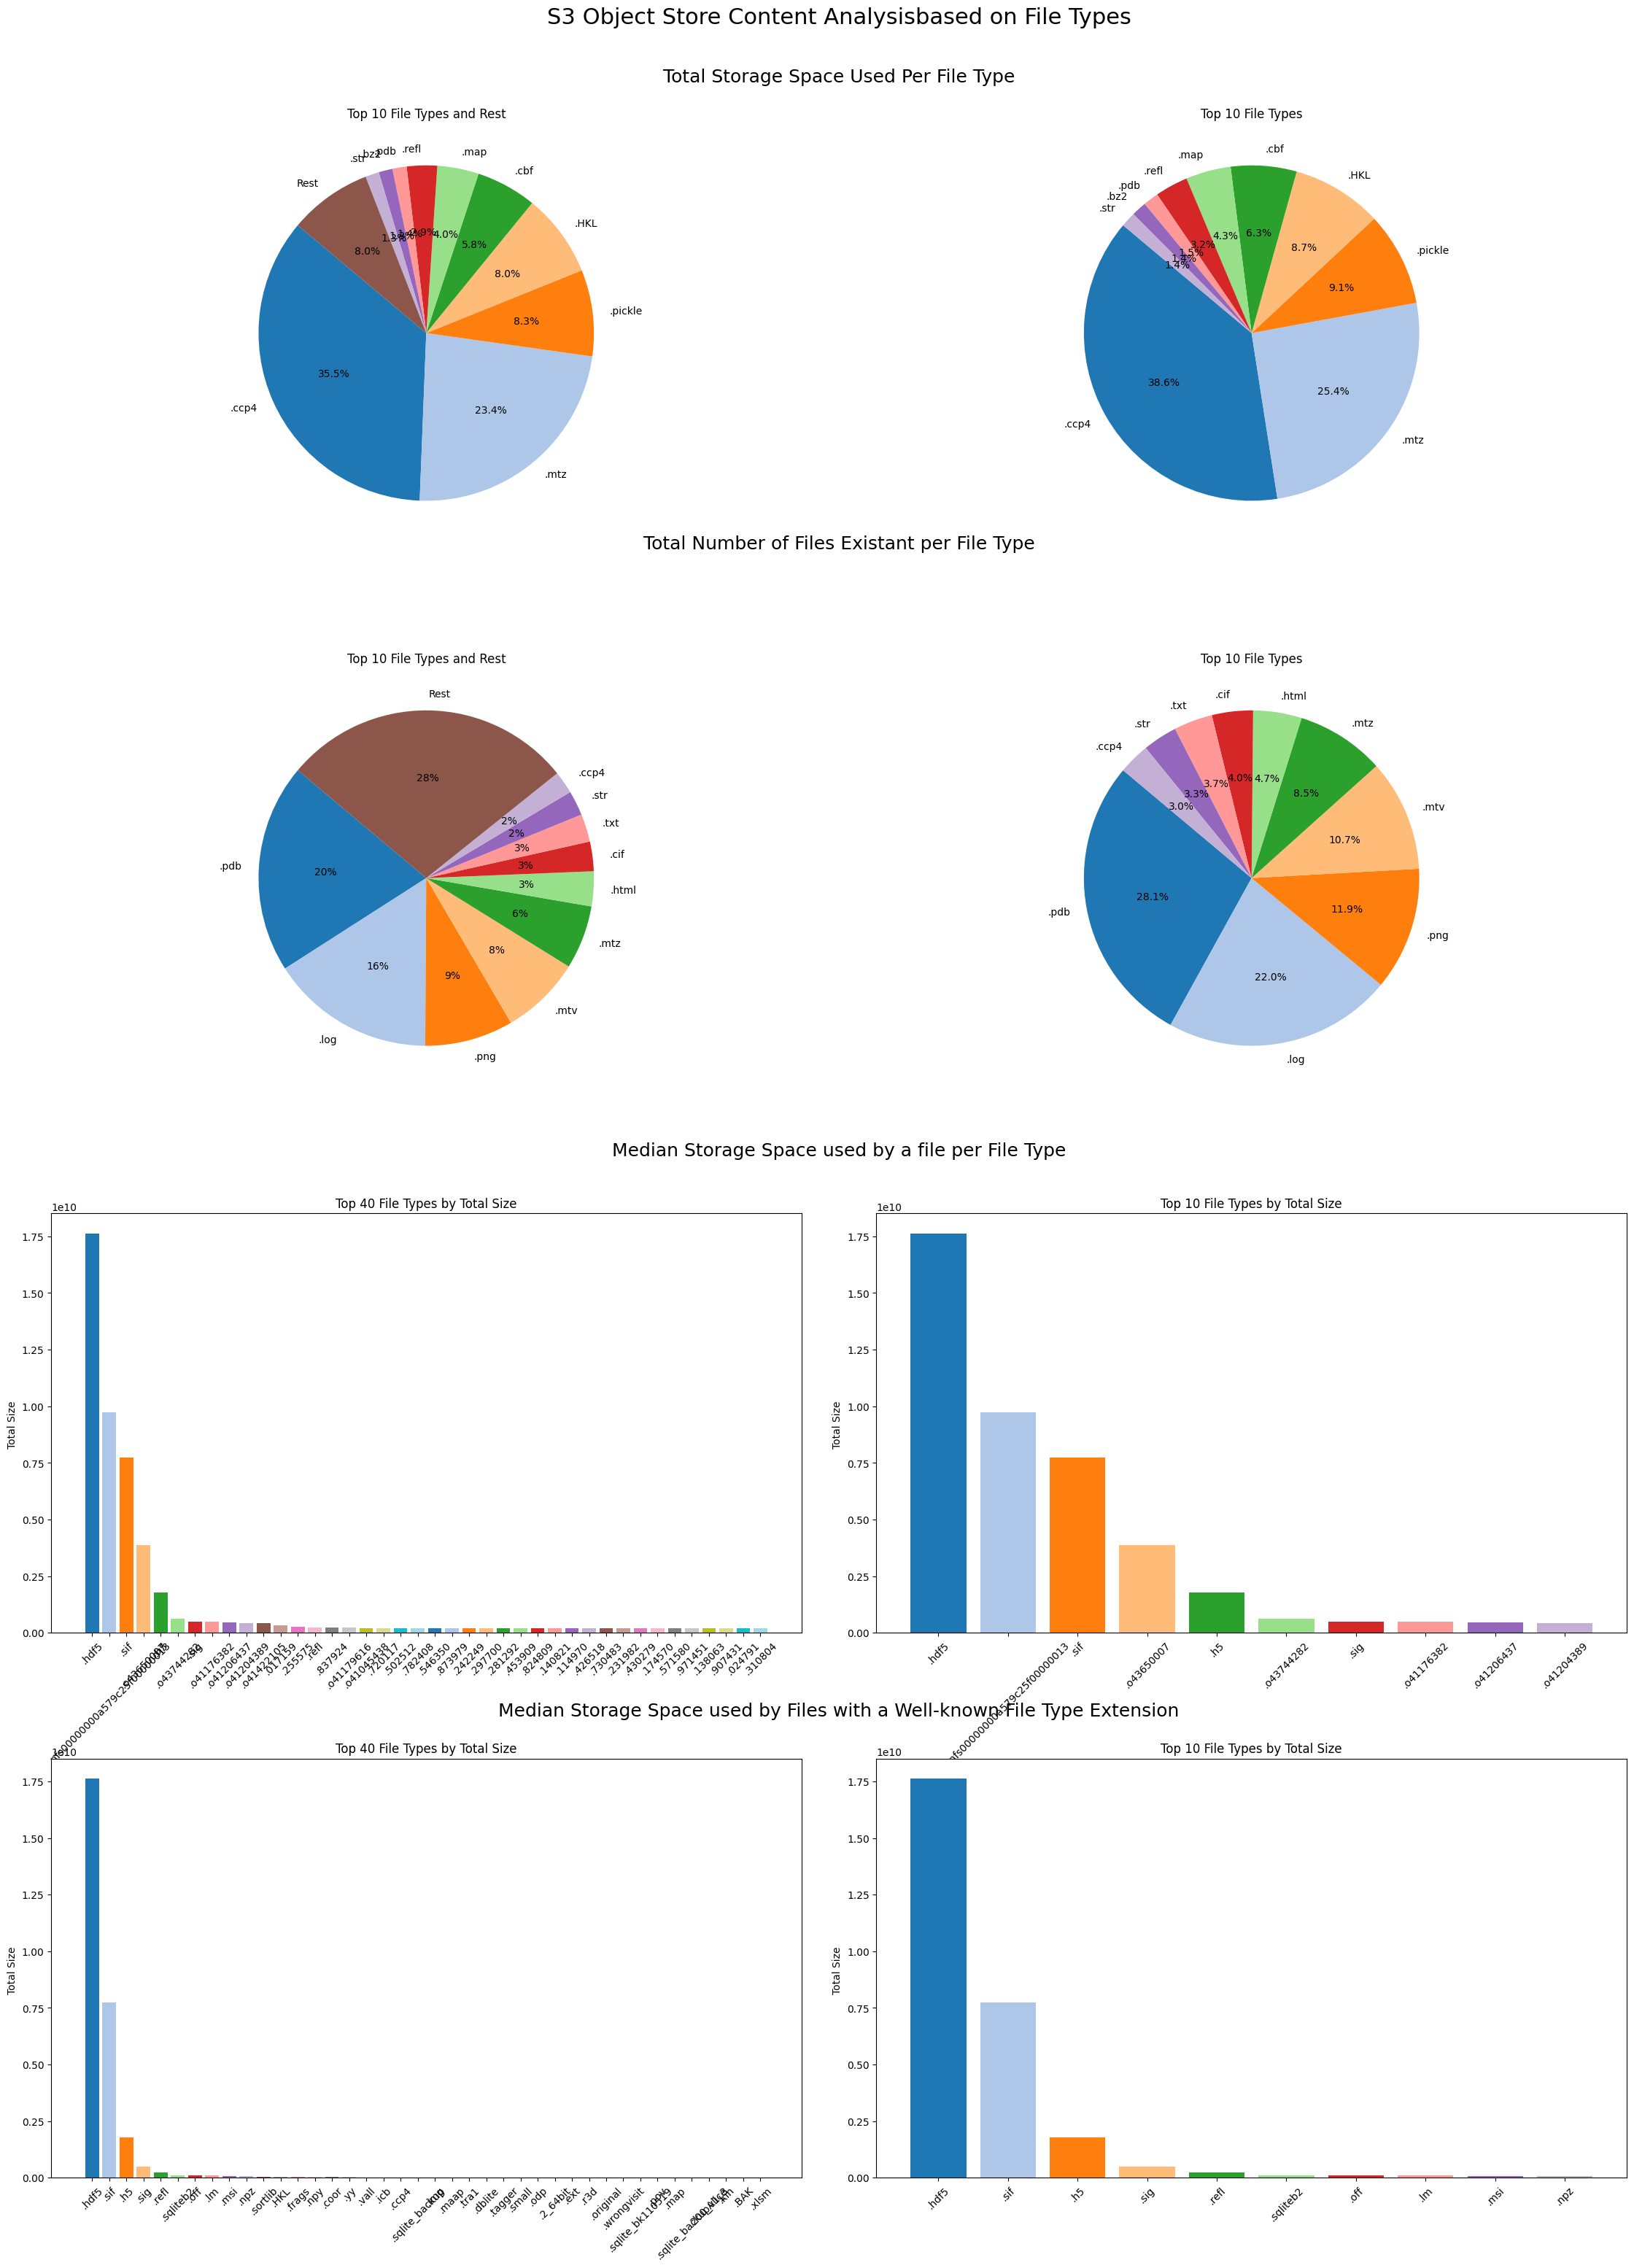

In [56]:
# Plotting the Data
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(4, 2, figsize=(24, 32))

fig.tight_layout(h_pad=2)


ax[0,0].pie( list(sums["Sum"][:10]) + [bucketSize - sum(sums["Sum"][:10])], labels= list(sums["File Type"][:10] ) + ["Rest"],
            colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
ax[0,0].set_title("Top 10 File Types and Rest")


ax[0,1].pie(sums["Sum"][:10], labels=sums["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
ax[0,1].set_title("Top 10 File Types")


ax[1,0].pie( list(counts["Files Count"][:10]) + [ bucketCount - sum(counts["Files Count"][:10])], labels = (list(counts["File Type"][:10] ) + ["Rest"] ),
            colors = sns.color_palette("tab20"),autopct='%.0f%%', startangle=140)
ax[1,0].set_title("Top 10 File Types and Rest")

ax[1,1].pie(counts["Files Count"][:10], labels=counts["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
ax[1,1].set_title("Top 10 File Types")




# ax[2,0].pie( list(median["Median"][:10]) + [ bucketMedians - sum(median["Files Count"][:10])], labels = (list(median["File Type"][:10] ) + ["Rest"] ),
#             colors = sns.color_palette("tab20"),autopct='%.0f%%', startangle=140)
# ax[2,0].set_title("Top 10 File Types and Rest")

# ax[2,1].pie(median["Median"][:10], labels=median["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
# ax[2,1].set_title("Top 10 File Types")



# ax[3,0].pie( list(filteredMedian["Median"][:10]) + [ bucketMedians - sum(filteredMedian["Files Count"][:10])], labels = (list(filteredMedian["File Type"][:10] ) + ["Rest"] ),
#             colors = sns.color_palette("tab20"),autopct='%.0f%%', startangle=140)
# ax[3,0].set_title("Top 10 Filtered Types and Rest")

# ax[3,1].pie(filteredMedian["Median"][:10], labels=filteredMedian["File Type"][:10],colors = sns.color_palette("tab20"), autopct='%1.1f%%', startangle=140)
# ax[3,1].set_title("Top 10 Filtered File Types")

size = 40

ax[2,0].bar(median["File Type"][:size], median["Median"][:size], color=sns.color_palette("tab20"))
ax[2,0].set_title(f"Top {size} File Types by Total Size")
ax[2,0].set_ylabel("Total Size ")
ax[2,0].tick_params(axis='x', rotation=45)

ax[2,1].bar(median["File Type"][:10], median["Median"][:10], color=sns.color_palette("tab20"))
ax[2,1].set_title("Top 10 File Types by Total Size")
ax[2,1].set_ylabel("Total Size ")
ax[2,1].tick_params(axis='x', rotation=45)




ax[3,0].bar(filteredMedian["File Type"][:size], filteredMedian["Median"][:size], color=sns.color_palette("tab20"))
ax[3,0].set_title(f"Top {size} File Types by Total Size")
ax[3,0].set_ylabel("Total Size ")
ax[3,0].tick_params(axis='x', rotation=45)

ax[3,1].bar(filteredMedian["File Type"][:10], filteredMedian["Median"][:10], color=sns.color_palette("tab20"))
ax[3,1].set_title("Top 10 File Types by Total Size")
ax[3,1].set_ylabel("Total Size ")
ax[3,1].tick_params(axis='x', rotation=45)




fig.suptitle("S3 Object Store Content Analysisbased on File Types", fontsize=22)
fig.text(0.5, 0.95, "Total Storage Space Used Per File Type", ha='center', va='center', fontsize=18)
fig.text(0.5, 0.75, "Total Number of Files Existant per File Type", ha='center', va='center', fontsize=18)
fig.text(0.5, 0.49, "Median Storage Space used by a file per File Type", ha='center', va='center', fontsize=18)
fig.text(0.5, 0.25, "Median Storage Space used by Files with a Well-known File Type Extension", ha='center', va='center', fontsize=18)

plt.subplots_adjust(top=0.93, bottom=0.05, left=0.05, right=0.95, hspace=0.3, wspace=0.1)
plt.show()

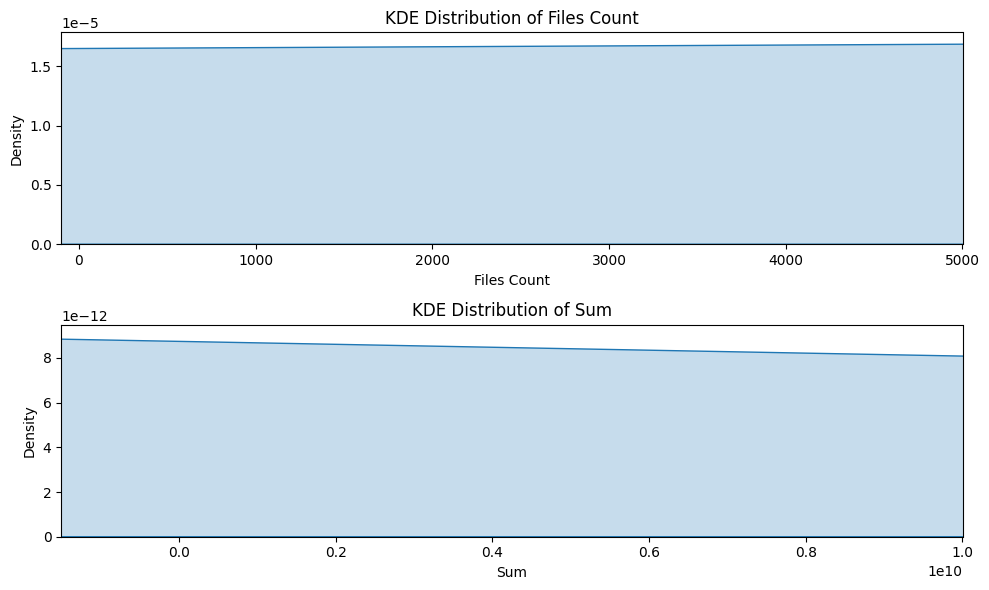

In [40]:
import seaborn as sns

import matplotlib.pyplot as plt

numeric_cols = ["Files Count", "Sum"] #  "Median", "Mean", "Std", "1stQrt", "3rdQrt", "QrtDeviation", "Max", "Min",

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(10, 3 * len(numeric_cols)))
for i, col in enumerate(numeric_cols):
    sns.kdeplot(dataStats_df[col], ax=axes[i], fill=True, gridsize=5000) # vbw_adjust=0.5
    axes[i].set_title(f"KDE Distribution of {col}")
axes[0].set_xlim(-0.1e3, 0.5e4)
axes[1].set_xlim(-1.5*1e9, 1*1e10)
plt.tight_layout()
plt.show()



## Variation and Distribution per File Type

In [ ]:
from xaidar.filesUtils import loadPickle

dataPath = Path( "../../data/s3Sizes/xchem/filetypes/merged_filetype_sizes.pkl" ) 
data = loadPickle( dataPath )

# data_df = pd.DataFrame( data )
# display( data_df.head(2))